<a href="https://colab.research.google.com/github/nandhnd/Fungi-Classification/blob/main/2318089_uts.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#DATASET

Sumber: https://www.kaggle.com/datasets/joebeachcapital/defungi/data

Dataset citra mikroskopik yang digunakan untuk klasifikasi jamur (fungi) secara langsung dari hasil pemeriksaan mikologi (direct mycological examination). Dataset ini berisi gambar dari infeksi jamur superfisial yang disebabkan oleh tiga kelompok utama, yaitu yeast (khamir), mould (kapang), dan dermatophyte fungi (jamur dermatofit).

Karakteristik data:
1. Format file.jpg (JPEG)
2. Jenis gambarCitra mikroskopik berwarna (RGB)
3. Jumlah kelas5 kelas (H1, H2, H3, H5, H6)
4. Total gambar9.114 gambar

Label:
- H1: jumlah 4.404, presentase 48,3%
- H2: jumlah 2.334, presentase 25,6%
- H3: jumlah 819, presentase 9,0%
- H5: jumlah 818, presentase 9,0%
- H6: jumlah 739, presentase 8,1%

Keterangan Label:
- H1: Tortuous septate hyaline hyphae (TSH), Hifa hialin bersepta dengan bentuk berliku-liku
- H2: Arthroconidial septate hyaline hyphae (BASH), Hifa hialin bersepta dengan artrokonidia
- H3: Groups or mosaics of arthroconidia (GMA), Kelompok atau mosaik artrokonidia
- H5: Septate hyaline hyphae with chlamydoconidia (SHC), Hifa hialin bersepta dengan klamidokonidia
- H6: Broad brown hyphae (BBH), Hifa coklat lebar (melanized/dematiaceous)

#1. IMPORT LIBRARY DAN LOAD DATASET

## IMPORT LIBRARY

In [17]:
# Install library scikit-image untuk ekstraksi fitur tekstur (GLCM)
# Flag -q artinya "quiet" → tidak menampilkan log instalasi yang panjang
!pip install scikit-image -q

import os                         # untuk navigasi folder dan path file
import numpy as np                # operasi array dan matriks numerik
import pandas as pd               # membuat dan mengelola DataFrame (tabel data)
import matplotlib.pyplot as plt   # membuat grafik dan visualisasi
import seaborn as sns             # visualisasi statistik yang lebih rapi
from PIL import Image             # membuka dan memanipulasi gambar (Pillow)

# graycomatrix : menghitung matriks co-occurrence piksel abu-abu (untuk GLCM)
# graycoprops  : menghitung properti/fitur dari matriks GLCM
from skimage.feature import graycomatrix, graycoprops

# rgb2gray : mengkonversi gambar RGB menjadi grayscale (1 channel)
from skimage.color import rgb2gray

# RandomForestClassifier : algoritma Random Forest untuk klasifikasi
from sklearn.ensemble import RandomForestClassifier

# train_test_split : membagi dataset menjadi data latih dan data uji
from sklearn.model_selection import train_test_split

# accuracy_score      : menghitung akurasi prediksi
# classification_report: laporan precision, recall, f1-score per kelas
# confusion_matrix    : matriks kebingungan prediksi vs aktual
# ConfusionMatrixDisplay: menampilkan confusion matrix sebagai plot
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

# LabelEncoder : mengubah label teks (H1,H2,...) menjadi angka (0,1,...)
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')  # sembunyikan pesan warning agar output lebih bersih


## LOAD DATASET

In [18]:
from google.colab import drive

# Hubungkan Google Drive ke Colab agar file di Drive bisa diakses
# Setelah dijalankan, akan muncul popup untuk izin akses → klik Allow
drive.mount('/content/drive')

# Path lokasi folder dataset di Google Drive
# Sesuaikan jika folder fungi_dataset ada di lokasi berbeda
DATASET_PATH = '/content/drive/MyDrive/KULIAH/semester 6/Computer Vision/UTS Klasifikasi Jamur/fungi_dataset'

# Ambil daftar subfolder dalam DATASET_PATH yang merupakan folder kelas
# os.listdir()  → list semua isi folder
# os.path.isdir() → filter hanya yang berupa folder (bukan file)
# sorted()      → urutkan nama kelas (H1, H2, H3, ...)
class_folders = sorted([
    d for d in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, d))
])
print(f"Kelas ditemukan: {class_folders}")

# Hitung jumlah gambar di setiap folder kelas
total = 0
for cls in class_folders:
    n = len(os.listdir(os.path.join(DATASET_PATH, cls)))  # hitung file dalam folder
    print(f"  {cls}: {n} gambar")
    total += n
print(f"Total keseluruhan: {total} gambar")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Kelas ditemukan: ['H1', 'H2', 'H3', 'H5', 'H6']
  H1: 4404 gambar
  H2: 2334 gambar
  H3: 819 gambar
  H5: 818 gambar
  H6: 739 gambar
Total keseluruhan: 9114 gambar


#2. FUNGSI EKSTRAKSI FITUR

In [19]:
def extract_hsv_histogram(image_rgb, bins=16):
    """
    Ekstraksi FITUR WARNA menggunakan Histogram HSV.

    HSV = Hue (warna), Saturation (kejenuhan), Value (kecerahan)
    Lebih baik dari RGB untuk analisis warna karena memisahkan
    informasi warna dari pencahayaan.

    Setiap channel dibagi menjadi 16 bin (kelompok nilai piksel),
    sehingga total fitur = 16 x 3 channel = 48 fitur.
    """
    # Konversi gambar RGB ke mode HSV menggunakan Pillow
    img_pil = Image.fromarray(image_rgb).convert('HSV')

    # Ubah objek PIL menjadi array numpy (H x W x 3)
    img_hsv = np.array(img_pil)

    features = []
    for channel in range(3):   # iterasi 3 channel: H=0, S=1, V=2
        # Hitung histogram: distribusi frekuensi nilai piksel
        # bins=16   → jumlah kelompok/bucket nilai piksel
        # range=(0,255) → rentang nilai piksel
        hist, _ = np.histogram(img_hsv[:, :, channel],
                               bins=bins, range=(0, 255))

        # Normalisasi histogram agar nilainya antara 0-1
        # +1e-6 untuk menghindari pembagian dengan nol (zero division)
        hist = hist / (hist.sum() + 1e-6)

        features.extend(hist)  # tambahkan 16 nilai bin ke list fitur
    return features             # mengembalikan 48 fitur warna


def extract_glcm_features(image_rgb):
    """
    Ekstraksi FITUR TEKSTUR menggunakan GLCM
    (Gray Level Co-occurrence Matrix).

    GLCM menganalisis pola hubungan antar piksel tetangga,
    sehingga dapat menangkap informasi tekstur seperti
    kasar/halus, bergaris, atau berbintik-bintik.

    Menghasilkan 5 properti tekstur:
    - Contrast     : seberapa besar perbedaan antar piksel tetangga
    - Dissimilarity: mirip contrast tapi lebih linier
    - Homogeneity  : seberapa seragam distribusi piksel
    - Energy       : keseragaman tekstur (ASM)
    - Correlation  : seberapa linier hubungan antar piksel
    """
    # Konversi gambar RGB ke grayscale (1 channel) karena
    # GLCM hanya bekerja pada gambar abu-abu
    gray = rgb2gray(image_rgb)  # nilai piksel antara 0.0 - 1.0

    # Konversi ke tipe uint8 (0-255) karena graycomatrix membutuhkannya
    gray_uint8 = (gray * 255).astype(np.uint8)

    # Hitung GLCM dengan parameter:
    # distances=[1] → jarak 1 piksel antar pasangan piksel
    # angles=[0, 45°, 90°, 135°] → 4 arah analisis tekstur
    # levels=256 → jumlah level intensitas abu-abu
    # symmetric=True → matriks simetris (arah bolak-balik dihitung sama)
    # normed=True → normalisasi matriks
    glcm = graycomatrix(gray_uint8, distances=[1],
                        angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                        levels=256, symmetric=True, normed=True)

    features = []
    for prop in ['contrast', 'dissimilarity', 'homogeneity',
                 'energy', 'correlation']:
        # Hitung nilai properti GLCM, lalu rata-rata dari 4 arah
        val = graycoprops(glcm, prop).mean()
        features.append(val)

    return features  # mengembalikan 5 fitur tekstur


def extract_features(image_path, img_size=(64, 64)):
    """
    Fungsi utama ekstraksi fitur — menggabungkan HSV + GLCM.

    Parameter:
    - image_path : path lengkap ke file gambar
    - img_size   : ukuran resize gambar sebelum ekstraksi (default 64x64)
                   Resize penting agar semua gambar punya dimensi sama

    Output: list 53 fitur (48 HSV + 5 GLCM)
    """
    # Buka gambar → paksa ke mode RGB (antisipasi gambar RGBA/grayscale)
    # Resize ke 64x64 piksel agar ukuran seragam dan proses lebih cepat
    img = Image.open(image_path).convert('RGB').resize(img_size)

    # Konversi gambar PIL ke array numpy untuk diproses
    img_array = np.array(img)

    hsv_feat  = extract_hsv_histogram(img_array)  # 48 fitur warna
    glcm_feat = extract_glcm_features(img_array)  # 5 fitur tekstur

    # Gabungkan kedua list fitur menjadi satu list (total 53 fitur)
    return hsv_feat + glcm_feat

#3. PROSES EKSTRAKSI FITUR SEMUA GAMBAR

In [20]:
# Batas maksimal gambar yang diambil per kelas (balanced sampling)
# Tujuan: agar setiap kelas punya jumlah data yang sama → model tidak bias
# 200 per kelas x 5 kelas = 1000 data total
MAX_PER_CLASS = 200

data   = []  # menampung list fitur dari setiap gambar
labels = []  # menampung label kelas dari setiap gambar
errors = 0   # menghitung gambar yang gagal diproses

print("\nMemulai ekstraksi fitur...\n")

for class_name in class_folders:   # iterasi setiap kelas (H1, H2, ...)
    class_path = os.path.join(DATASET_PATH, class_name)  # path folder kelas

    # Ambil semua file gambar dalam folder kelas
    # Filter hanya file dengan ekstensi gambar yang valid
    images = sorted([
        f for f in os.listdir(class_path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ])

    # Batasi jumlah gambar per kelas sesuai MAX_PER_CLASS
    # Jika MAX_PER_CLASS = None, semua gambar akan diproses
    if MAX_PER_CLASS:
        images = images[:MAX_PER_CLASS]

    print(f"  [{class_name}] {len(images)} gambar diproses...", end=' ')

    for img_file in images:
        img_path = os.path.join(class_path, img_file)  # path lengkap file gambar
        try:
            feats = extract_features(img_path)  # ekstrak 53 fitur dari gambar
            data.append(feats)                  # simpan fitur ke list data
            labels.append(class_name)           # simpan label kelas yang sesuai
        except Exception as e:
            errors += 1  # hitung gambar yang error (corrupt/format salah)

    print("✓")

print(f"\nEkstraksi selesai! Total: {len(data)} data | Error: {errors}")


Memulai ekstraksi fitur...

  [H1] 200 gambar diproses... ✓
  [H2] 200 gambar diproses... ✓
  [H3] 200 gambar diproses... ✓
  [H5] 200 gambar diproses... ✓
  [H6] 200 gambar diproses... ✓

Ekstraksi selesai! Total: 1000 data | Error: 0


#4. MEMBUAT DATAFRAME FITUR

In [21]:
# Buat nama kolom untuk 48 fitur warna HSV (H0 sampai H47)
col_hsv  = [f'H{i}' for i in range(48)]

# Buat nama kolom untuk 5 fitur tekstur GLCM (T0 sampai T4)
col_glcm = [f'T{i}' for i in range(5)]

# Gabungkan semua nama kolom → total 53 kolom fitur
columns  = col_hsv + col_glcm

# Buat DataFrame dari list data (setiap baris = 1 gambar, setiap kolom = 1 fitur)
df = pd.DataFrame(data, columns=columns)

# Tambahkan kolom 'label' berisi nama kelas (H1, H2, H3, H5, H6)
df['label'] = labels

print("\n── Preview DataFrame ──")
print(df.head(3))                          # tampilkan 3 baris pertama
print(f"\nShape  : {df.shape}  (baris x kolom)")
print(f"\nDistribusi kelas:")
print(df['label'].value_counts())          # hitung jumlah data per kelas


── Preview DataFrame ──
         H0        H1        H2        H3        H4        H5        H6  \
0  0.032227  0.033936  0.040039  0.090820  0.125732  0.140869  0.084717   
1  0.024658  0.016846  0.025146  0.053467  0.097900  0.122070  0.127197   
2  0.018311  0.010498  0.015625  0.034912  0.062012  0.101562  0.187500   

         H7        H8        H9  ...  H44  H45  H46  H47          T0  \
0  0.051758  0.026855  0.046387  ...  0.0  0.0  0.0  0.0  112.482535   
1  0.095215  0.042725  0.093262  ...  0.0  0.0  0.0  0.0   60.077429   
2  0.218994  0.057373  0.135498  ...  0.0  0.0  0.0  0.0   33.546133   

         T1        T2        T3        T4  label  
0  8.174861  0.120277  0.027466  0.738856     H1  
1  5.502180  0.213620  0.040663  0.816023     H1  
2  3.492563  0.361944  0.078251  0.837453     H1  

[3 rows x 54 columns]

Shape  : (1000, 54)  (baris x kolom)

Distribusi kelas:
label
H1    200
H2    200
H3    200
H5    200
H6    200
Name: count, dtype: int64


#5. SIMPAN DATAFRAME KE FILE CSV

In [22]:
# Simpan DataFrame ke file CSV di Google Drive
# File ini bisa dijadikan lampiran tugas sebagai bukti dataset fitur
csv_path = '/content/drive/MyDrive/KULIAH/semester 6/Computer Vision/UTS Klasifikasi Jamur/defungi_features.csv'
df.to_csv(csv_path, index=False)  # index=False → tidak menyimpan nomor baris
print(f"\nCSV disimpan ke Drive: {csv_path}")


CSV disimpan ke Drive: /content/drive/MyDrive/KULIAH/semester 6/Computer Vision/UTS Klasifikasi Jamur/defungi_features.csv


#6. PEMBAGIAN DATA LATIH DAN DATA UJI

In [23]:
# X = matriks fitur (semua kolom kecuali 'label'), bentuk (1000 x 53)
X = df.drop('label', axis=1).values

# y = array label kelas dalam bentuk teks ['H1','H1','H2',...]
y = df['label'].values

# Inisialisasi LabelEncoder untuk mengubah label teks ke angka
le = LabelEncoder()

# fit_transform: pelajari pemetaan label → langsung ubah ke angka
# H1=0, H2=1, H3=2, H5=3, H6=4 (urutan sesuai abjad)
y_enc = le.fit_transform(y)

# Bagi data: 80% untuk training, 20% untuk testing
# random_state=42 → hasil pembagian selalu sama setiap dijalankan (reproducible)
# stratify=y_enc  → pastikan proporsi kelas sama di data latih dan uji
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

print(f"\nData training : {X_train.shape[0]} sampel")  # 800 sampel (80%)
print(f"Data testing  : {X_test.shape[0]} sampel")    # 200 sampel (20%)


Data training : 800 sampel
Data testing  : 200 sampel


#7. TRAINING MODEL RANDOM FOREST

In [24]:
print("\nTraining Random Forest... ", end='')

# Inisialisasi model Random Forest dengan parameter:
# n_estimators=100 → jumlah pohon keputusan (decision tree) yang dibuat
#                    semakin banyak pohon = lebih stabil, tapi lebih lambat
# random_state=42  → agar hasil training sama setiap dijalankan
# n_jobs=-1        → gunakan semua core CPU yang tersedia (proses paralel)
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Latih model menggunakan data training
# Model akan membangun 100 decision tree dari data X_train
rf.fit(X_train, y_train)
print("selesai!")


Training Random Forest... selesai!


#8. EVALUASI MODEL

In [25]:
# Gunakan model yang sudah dilatih untuk memprediksi data uji
y_pred = rf.predict(X_test)

# Hitung akurasi: jumlah prediksi benar / total prediksi
acc = accuracy_score(y_test, y_pred)

print(f"\n{'='*45}")
print(f"  AKURASI MODEL : {acc * 100:.2f}%")
print(f"{'='*45}\n")

# Tampilkan laporan lengkap per kelas:
# Precision : dari semua yang diprediksi kelas X, berapa % yang benar?
# Recall    : dari semua yang aslinya kelas X, berapa % yang terdeteksi?
# F1-score  : rata-rata harmonis precision dan recall
# Support   : jumlah data uji per kelas
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))


  AKURASI MODEL : 92.50%

Classification Report:
              precision    recall  f1-score   support

          H1       0.90      0.95      0.93        40
          H2       0.89      1.00      0.94        40
          H3       0.92      0.88      0.90        40
          H5       1.00      0.97      0.99        40
          H6       0.92      0.82      0.87        40

    accuracy                           0.93       200
   macro avg       0.93      0.93      0.92       200
weighted avg       0.93      0.93      0.92       200



#9. VISUALISASI CONFUSION MATRIX

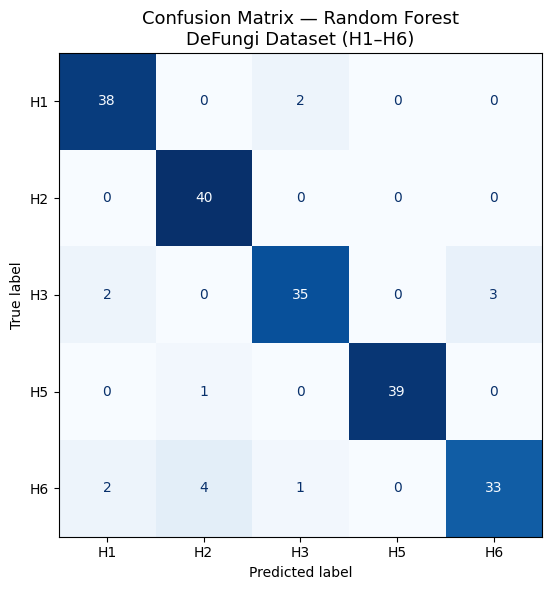

In [26]:
fig, ax = plt.subplots(figsize=(8, 6))  # buat kanvas plot ukuran 8x6 inci

# Hitung confusion matrix:
# Baris = kelas aktual, Kolom = kelas prediksi
# Nilai diagonal = prediksi benar, nilai lain = prediksi salah
cm = confusion_matrix(y_test, y_pred)

# Buat objek display confusion matrix dengan nama kelas asli (H1, H2, ...)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=le.classes_)

# Tampilkan sebagai plot dengan warna biru (Blues colormap)
disp.plot(ax=ax, cmap='Blues', colorbar=False)

plt.title('Confusion Matrix — Random Forest\nDeFungi Dataset (H1–H6)',
          fontsize=13)
plt.tight_layout()  # atur jarak antar elemen plot agar tidak tumpang tindih

plt.show()  # tampilkan plot di output Colab

#10. VISUALISASI FEATURE IMPORTANCE

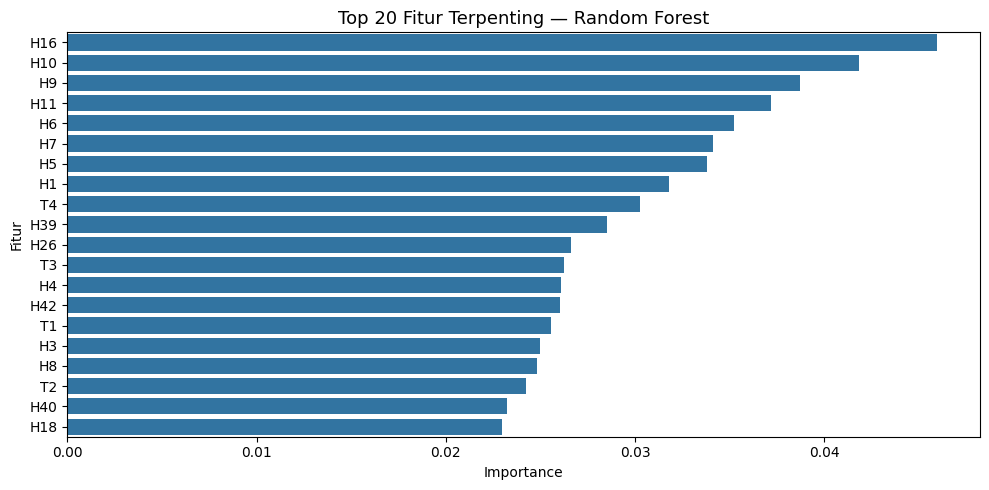

In [27]:
# Ambil nilai feature importance dari model Random Forest
# Nilai ini menunjukkan seberapa besar kontribusi tiap fitur
# dalam pengambilan keputusan klasifikasi (range 0.0 - 1.0)
feat_df = pd.DataFrame({
    'Fitur'     : columns,                  # nama fitur (H0..H47, T0..T4)
    'Importance': rf.feature_importances_   # skor kepentingan tiap fitur
}).sort_values('Importance', ascending=False).head(20)  # ambil top 20

plt.figure(figsize=(10, 5))

# Buat bar chart horizontal: sumbu X = importance, sumbu Y = nama fitur
sns.barplot(x='Importance', y='Fitur', data=feat_df)

plt.title('Top 20 Fitur Terpenting — Random Forest', fontsize=13)
plt.tight_layout()

plt.show()